# 问题二：目标差分 + 0.1 零值映射 + Hurdle 模型 + 最佳 lag

本 notebook 的建模流程为：

```text
1. 对 FILT. NTU 做一阶差分，并截断到 [-1, 1]
2. 将绝对值小于 0.1 的差分映射为 0
3. 每个输入变量只保留训练集上相关性最高的 lag
4. 随机划分 80% train / 20% test
5. Hurdle 第一阶段：XGBoost 判断差分是否非零
6. Hurdle 第二阶段：仅使用非零训练样本，分别训练 MLP、LightGBM、Random Forest
7. 分类器预测为零时最终预测为 0，否则使用对应第二阶段回归值
```

目标变换为：

```text
Δ_t = clip(FILT.NTU_t - FILT.NTU_{t-1}, -1, 1)
y_t = 0,       if |Δ_t| < 0.1
y_t = Δ_t,     otherwise
```

输出目录：

```text
outputs/problem2_diff_hurdle01_bestlag_random80/
```

## 1. 导入依赖库

第一阶段需要 XGBoost，第二阶段需要 LightGBM。若环境缺少对应库，建模单元会给出明确错误。

In [1]:
from pathlib import Path
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except Exception as e:
    XGB_AVAILABLE = False
    XGB_IMPORT_ERROR = e

try:
    from lightgbm import LGBMRegressor
    LGBM_AVAILABLE = True
except Exception as e:
    LGBM_AVAILABLE = False
    LGBM_IMPORT_ERROR = e

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 220)
pd.set_option("display.width", 260)

print("XGBoost available:", XGB_AVAILABLE)
print("LightGBM available:", LGBM_AVAILABLE)

XGBoost available: True
LightGBM available: True


## 2. 参数设置

这里保持流程清晰，不做复杂超参数搜索。


In [2]:
TARGET_COL = "FILT. NTU"
OUTPUT_DIR_NAME = "problem2_diff_hurdle01_level_evaluation"

RANDOM_STATE = 42
TEST_SIZE = 0.20
RECORD_INTERVAL_HOURS = 2

DIFF_CLIP_LOWER = -1.0
DIFF_CLIP_UPPER = 1.0
DIFF_ZERO_THRESHOLD = 0.1

STAGE1_CV_FOLDS = 5
STAGE1_WEIGHT_CANDIDATES = [1.0, 2.0, 4.0, 6.0]
STAGE1_THRESHOLD_CANDIDATES = np.round(np.arange(0.30, 0.81, 0.05), 2)

CORE_FEATURES = [
    "R/W NTU",
    "R/W PH",
    "ALUM",
    "F/RIDE",
    "R/W FLOW",
]

EXOG_LEVEL_LAGS = list(range(0, 7))
TARGET_DIFF_HISTORY_LAGS = [1, 2, 3]
CLIP_PREDICTIONS = True

print("参数设置完成。")

参数设置完成。


## 3. 自动定位 `merged.xlsx`

从原始 `merged.xlsx` 读取，不依赖任何中间文件。


In [3]:
def locate_merged_file(filename="merged.xlsx"):
    cwd = Path.cwd().resolve()
    candidates = []

    search_roots = [cwd] + list(cwd.parents)

    for root in search_roots:
        candidates.extend([
            root / "data" / filename,
            root / "codes" / "data" / filename,
            root / "2026-Asia-Pacific-cup" / "data" / filename,
            root / "2026-Asia-Pasific-cup" / "data" / filename,
            root / filename,
        ])

    seen = set()
    unique_candidates = []

    for p in candidates:
        p = p.resolve()
        if p not in seen:
            seen.add(p)
            unique_candidates.append(p)

    for p in unique_candidates:
        if p.exists():
            return p

    for p in cwd.rglob(filename):
        return p.resolve()

    for parent in cwd.parents:
        try:
            for p in parent.rglob(filename):
                return p.resolve()
        except Exception:
            pass

    searched = "\n".join(str(p) for p in unique_candidates)
    raise FileNotFoundError(f"未找到 {filename}。已检查路径：\n{searched}")


DATA_PATH = locate_merged_file()
DATA_DIR = DATA_PATH.parent

if DATA_DIR.name == "data":
    PROJECT_DIR = DATA_DIR.parent
else:
    PROJECT_DIR = DATA_DIR

OUTPUT_DIR = PROJECT_DIR / "outputs" / OUTPUT_DIR_NAME
FIG_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("当前工作目录：", Path.cwd().resolve())
print("使用数据文件：", DATA_PATH)
print("输出目录：", OUTPUT_DIR)


当前工作目录： /Users/jinyu/workspace/2026亚太杯/codes/p2
使用数据文件： /Users/jinyu/workspace/2026亚太杯/data/merged.xlsx
输出目录： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_hurdle01_level_evaluation


## 4. 读取数据并构造时间列

构造：

```text
DATETIME
OP_DATE
```

`OP_DATE` 使用运行日定义：

```text
07:00 至次日 05:00 归为同一个运行日
```


In [4]:
df = pd.read_excel(DATA_PATH)

print("原始数据规模：", df.shape)
print("原始列名：")
print(df.columns.tolist())

if TARGET_COL not in df.columns:
    raise ValueError(f"未找到目标变量 {TARGET_COL}。请检查 merged.xlsx。")


def construct_datetime(data):
    data = data.copy()

    if "DATETIME" in data.columns:
        data["DATETIME"] = pd.to_datetime(data["DATETIME"], errors="coerce")
        return data

    date_candidates = ["DATE", "Date", "date"]
    time_candidates = ["TIME", "Time", "time"]

    date_col = next((c for c in date_candidates if c in data.columns), None)
    time_col = next((c for c in time_candidates if c in data.columns), None)

    if date_col is None or time_col is None:
        raise ValueError("无法构造 DATETIME：需要 DATE 和 TIME 两列，或已有 DATETIME 列。")

    date_text = data[date_col].astype(str).str.split().str[0]
    time_text = data[time_col].astype(str).str.split().str[-1]

    data["DATETIME"] = pd.to_datetime(
        date_text + " " + time_text,
        errors="coerce",
    )

    return data


df = construct_datetime(df)
df = df.dropna(subset=["DATETIME"]).sort_values("DATETIME").reset_index(drop=True)

df["OP_DATE"] = df["DATETIME"].dt.date
mask_before_7 = df["DATETIME"].dt.hour < 7
df.loc[mask_before_7, "OP_DATE"] = (
    df.loc[mask_before_7, "DATETIME"] - pd.Timedelta(days=1)
).dt.date

print("时间范围：", df["DATETIME"].min(), "至", df["DATETIME"].max())
display(df[["DATETIME", "OP_DATE", TARGET_COL]].head(12))


原始数据规模： (5460, 18)
原始列名：
['DATE', 'TIME', 'RIVER LEVEL', 'R/W PUMP DUTY', 'R/W FLOW', 'R/W NTU', 'R/W CLR', 'R/W PH', 'FILT. NTU', 'C/W WELL LEVEL', 'PH', 'NTU', 'CLR', 'CL2', 'F/RIDE', 'ALUM', 'T/W PUMP DUTY', 'T/W FLOW']
时间范围： 2025-01-01 07:00:00 至 2026-04-01 05:00:00


,DATETIME,OP_DATE,FILT. NTU
0,2025-01-01 07:00:00,2025-01-01,0.04
1,2025-01-01 09:00:00,2025-01-01,0.05
2,2025-01-01 11:00:00,2025-01-01,0.05
3,2025-01-01 13:00:00,2025-01-01,0.05
4,2025-01-01 15:00:00,2025-01-01,0.05
5,2025-01-01 17:00:00,2025-01-01,0.06
6,2025-01-01 19:00:00,2025-01-01,0.05
7,2025-01-01 21:00:00,2025-01-01,0.05
8,2025-01-01 23:00:00,2025-01-01,0.05
9,2025-01-02 01:00:00,2025-01-01,0.05


## 5. 缺失值处理

处理原则：

```text
1. 只保留第二问目标变量和核心输入变量；
2. 所有变量转为 numeric；
3. F/RIDE 缺失值填 0，R/W PH 缺失值填 7，ALUM 缺失值填 0.06；
4. 除上述三个变量外，其余变量按时间顺序进行线性插值；
5. 插值后仍缺失的值再 forward fill / backward fill；
6. 后续模型 pipeline 内仍保留 SimpleImputer(strategy='median')，防止 lag 特征产生的少量缺失影响训练。
```

输出：

```text
problem2_diff_clip1_missing_audit.xlsx
```


In [5]:
available_features = [c for c in CORE_FEATURES if c in df.columns]
missing_features = [c for c in CORE_FEATURES if c not in df.columns]

print("可用核心输入变量：", available_features)
print("缺失核心输入变量：", missing_features)

use_cols = ["DATETIME", "OP_DATE", TARGET_COL] + available_features
use_cols = list(dict.fromkeys(use_cols))

data = df[use_cols].copy().sort_values("DATETIME").reset_index(drop=True)

# 转 numeric
for col in [TARGET_COL] + available_features:
    data[col] = pd.to_numeric(data[col], errors="coerce")

missing_before = pd.DataFrame({
    "column": [TARGET_COL] + available_features,
    "missing_count_before": [int(data[c].isna().sum()) for c in [TARGET_COL] + available_features],
    "missing_rate_before": [float(data[c].isna().mean()) for c in [TARGET_COL] + available_features],
})

# 指定变量使用固定值填充
fixed_fill_values = {
    "F/RIDE": 0,
    "R/W PH": 7,
    "ALUM": 0.06,
}
for col, fill_value in fixed_fill_values.items():
    if col in data.columns:
        data[col] = data[col].fillna(fill_value)

# 其他变量线性插值 + 前后填充
for col in [TARGET_COL] + available_features:
    if col in fixed_fill_values:
        continue

    data[col] = (
        data[col]
        .interpolate(method="linear", limit_direction="both")
        .ffill()
        .bfill()
    )

missing_after = pd.DataFrame({
    "column": [TARGET_COL] + available_features,
    "missing_count_after": [int(data[c].isna().sum()) for c in [TARGET_COL] + available_features],
    "missing_rate_after": [float(data[c].isna().mean()) for c in [TARGET_COL] + available_features],
})

missing_audit = missing_before.merge(missing_after, on="column", how="left")

missing_audit_path = OUTPUT_DIR / "problem2_diff_clip1_missing_audit.xlsx"
missing_audit.to_excel(missing_audit_path, index=False)

print("缺失值处理审计表已保存：", missing_audit_path)
display(missing_audit)

print("处理后数据规模：", data.shape)
display(data.head())


可用核心输入变量： ['R/W NTU', 'R/W PH', 'ALUM', 'F/RIDE', 'R/W FLOW']
缺失核心输入变量： []
缺失值处理审计表已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_hurdle01_level_evaluation/problem2_diff_clip1_missing_audit.xlsx


,column,missing_count_before,missing_rate_before,missing_count_after,missing_rate_after
0,FILT. NTU,0,0.000000,0,0.0
1,R/W NTU,0,0.000000,0,0.0
2,R/W PH,1644,0.301099,0,0.0
3,ALUM,1644,0.301099,0,0.0
4,F/RIDE,0,0.000000,0,0.0
5,R/W FLOW,0,0.000000,0,0.0


处理后数据规模： (5460, 8)


,DATETIME,OP_DATE,FILT. NTU,R/W NTU,R/W PH,ALUM,F/RIDE,R/W FLOW
0,2025-01-01 07:00:00,2025-01-01,0.04,150,7.0,0.04,0.0,45.3
1,2025-01-01 09:00:00,2025-01-01,0.05,120,7.0,0.04,0.0,45.2
2,2025-01-01 11:00:00,2025-01-01,0.05,82,7.0,0.04,0.0,44.9
3,2025-01-01 13:00:00,2025-01-01,0.05,62,7.0,0.04,0.0,44.9
4,2025-01-01 15:00:00,2025-01-01,0.05,56,7.0,0.04,0.0,44.5


## 6. 差分处理：当前值 - 前一个时间节点值

对目标变量和核心输入变量都做一阶差分：

```text
DIFF_X_t = X_t - X_{t-1}
```

输出：

```text
problem2_diff_raw_data.xlsx
```


In [6]:
def safe_name(col):
    return (
        str(col)
        .replace("/", "_")
        .replace(" ", "_")
        .replace(".", "")
        .replace("+", "plus")
        .replace("-", "_")
    )


diff_data = data.copy()

target_diff_col = f"DIFF_{safe_name(TARGET_COL)}"
previous_target_col = f"PREVIOUS_{safe_name(TARGET_COL)}"
diff_data[previous_target_col] = diff_data[TARGET_COL].shift(1)
diff_data[target_diff_col] = diff_data[TARGET_COL] - diff_data[previous_target_col]

diff_raw_path = OUTPUT_DIR / "problem2_diff_raw_data.xlsx"
diff_data[["DATETIME", "OP_DATE", previous_target_col, TARGET_COL] + available_features + [target_diff_col]].to_excel(diff_raw_path, index=False)

print("原始差分数据已保存：", diff_raw_path)
print("目标差分列：", target_diff_col)
display(diff_data[["DATETIME", "OP_DATE", previous_target_col, TARGET_COL, target_diff_col] + available_features].head(12))


原始差分数据已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_hurdle01_level_evaluation/problem2_diff_raw_data.xlsx
目标差分列： DIFF_FILT_NTU


,DATETIME,OP_DATE,PREVIOUS_FILT_NTU,FILT. NTU,DIFF_FILT_NTU,R/W NTU,R/W PH,ALUM,F/RIDE,R/W FLOW
0,2025-01-01 07:00:00,2025-01-01,NaN,0.04,NaN,150,7.0,0.04,0.0,45.3
1,2025-01-01 09:00:00,2025-01-01,0.04,0.05,0.01,120,7.0,0.04,0.0,45.2
2,2025-01-01 11:00:00,2025-01-01,0.05,0.05,0.00,82,7.0,0.04,0.0,44.9
3,2025-01-01 13:00:00,2025-01-01,0.05,0.05,0.00,62,7.0,0.04,0.0,44.9
4,2025-01-01 15:00:00,2025-01-01,0.05,0.05,0.00,56,7.0,0.04,0.0,44.5
5,2025-01-01 17:00:00,2025-01-01,0.05,0.06,0.01,75,7.0,0.04,0.0,44.5
6,2025-01-01 19:00:00,2025-01-01,0.06,0.05,-0.01,102,7.0,0.04,0.0,44.2
7,2025-01-01 21:00:00,2025-01-01,0.05,0.05,0.00,99,7.0,0.04,0.0,44.2
8,2025-01-01 23:00:00,2025-01-01,0.05,0.05,0.00,100,7.0,0.04,0.0,48.9
9,2025-01-02 01:00:00,2025-01-01,0.05,0.05,0.00,67,7.0,0.04,0.0,48.6


## 7. 截断差分并映射小变化为 0

先将目标差分截断到 `[-1, 1]`，再应用零值门槛：

```python
clipped = np.clip(diff_value, -1, 1)
hurdle_target = 0 if abs(clipped) < 0.1 else clipped
```

等于 `0.1` 的值保留为非零值。

In [7]:
clip_data = diff_data.copy()

target_clip_col = f"{target_diff_col}_CLIP1"
target_hurdle_col = f"{target_clip_col}_HURDLE01"

clip_data[target_clip_col] = clip_data[target_diff_col].clip(
    lower=DIFF_CLIP_LOWER,
    upper=DIFF_CLIP_UPPER,
)
clip_data[target_hurdle_col] = clip_data[target_clip_col].mask(
    clip_data[target_clip_col].abs() < DIFF_ZERO_THRESHOLD,
    0.0,
)

valid_raw = clip_data[target_diff_col].dropna()
valid_clip = clip_data[target_clip_col].dropna()
valid_hurdle = clip_data[target_hurdle_col].dropna()

clip_audit_df = pd.DataFrame([{
    "original_variable": TARGET_COL,
    "diff_column": target_diff_col,
    "clip_column": target_clip_col,
    "hurdle_target_column": target_hurdle_col,
    "zero_threshold_absolute": DIFF_ZERO_THRESHOLD,
    "raw_diff_min": valid_raw.min() if len(valid_raw) else np.nan,
    "raw_diff_max": valid_raw.max() if len(valid_raw) else np.nan,
    "clip_min": valid_clip.min() if len(valid_clip) else np.nan,
    "clip_max": valid_clip.max() if len(valid_clip) else np.nan,
    "count_mapped_to_zero": int((
        (clip_data[target_clip_col].notna())
        & (clip_data[target_clip_col].abs() < DIFF_ZERO_THRESHOLD)
    ).sum()),
    "zero_count_after_mapping": int((valid_hurdle == 0).sum()),
    "nonzero_count_after_mapping": int((valid_hurdle != 0).sum()),
    "nonzero_rate_after_mapping": float((valid_hurdle != 0).mean()),
}])

clip_audit_path = OUTPUT_DIR / "problem2_diff_hurdle01_audit.xlsx"
clip_data_path = OUTPUT_DIR / "problem2_diff_hurdle01_data.xlsx"

clip_audit_df.to_excel(clip_audit_path, index=False)
clip_data[
    ["DATETIME", "OP_DATE", previous_target_col, TARGET_COL, target_diff_col, target_clip_col, target_hurdle_col]
    + available_features
].to_excel(clip_data_path, index=False)

print("差分与零值映射审计表已保存：", clip_audit_path)
print("Hurdle 目标数据已保存：", clip_data_path)
display(clip_audit_df)
display(
    clip_data[
        ["DATETIME", "OP_DATE", target_diff_col, target_clip_col, target_hurdle_col]
        + available_features
    ].head(30)
)

差分与零值映射审计表已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_hurdle01_level_evaluation/problem2_diff_hurdle01_audit.xlsx
Hurdle 目标数据已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_hurdle01_level_evaluation/problem2_diff_hurdle01_data.xlsx


,original_variable,diff_column,clip_column,hurdle_target_column,zero_threshold_absolute,raw_diff_min,raw_diff_max,clip_min,clip_max,count_mapped_to_zero,zero_count_after_mapping,nonzero_count_after_mapping,nonzero_rate_after_mapping
0,FILT. NTU,DIFF_FILT_NTU,DIFF_FILT_NTU_CLIP1,DIFF_FILT_NTU_CLIP1_HURDLE01,0.1,-3.89,7.6,-1.0,1.0,5003,5003,456,0.083532


,DATETIME,OP_DATE,DIFF_FILT_NTU,DIFF_FILT_NTU_CLIP1,DIFF_FILT_NTU_CLIP1_HURDLE01,R/W NTU,R/W PH,ALUM,F/RIDE,R/W FLOW
0,2025-01-01 07:00:00,2025-01-01,NaN,NaN,NaN,150,7.0,0.04,0.0,45.3
1,2025-01-01 09:00:00,2025-01-01,0.01,0.01,0.0,120,7.0,0.04,0.0,45.2
2,2025-01-01 11:00:00,2025-01-01,0.00,0.00,0.0,82,7.0,0.04,0.0,44.9
3,2025-01-01 13:00:00,2025-01-01,0.00,0.00,0.0,62,7.0,0.04,0.0,44.9
4,2025-01-01 15:00:00,2025-01-01,0.00,0.00,0.0,56,7.0,0.04,0.0,44.5
5,2025-01-01 17:00:00,2025-01-01,0.01,0.01,0.0,75,7.0,0.04,0.0,44.5
6,2025-01-01 19:00:00,2025-01-01,-0.01,-0.01,0.0,102,7.0,0.04,0.0,44.2
7,2025-01-01 21:00:00,2025-01-01,0.00,0.00,0.0,99,7.0,0.04,0.0,44.2
8,2025-01-01 23:00:00,2025-01-01,0.00,0.00,0.0,100,7.0,0.04,0.0,48.9
9,2025-01-02 01:00:00,2025-01-01,0.00,0.00,0.0,67,7.0,0.04,0.0,48.6


## 8. 构造建模特征：每组只保留相关性最高的 lag

外生变量从 `lag0-lag6` 中选择训练集上绝对 Spearman 相关性最高的一项；目标历史从 hurdle 目标的 `lag1-lag3` 中选择一项。相关性选择仅使用训练样本。

In [8]:
model_df = clip_data.copy()

target_name = "target_DIFF_FILT_NTU_HURDLE01"
model_df[target_name] = model_df[target_hurdle_col]

candidate_feature_records = []
candidate_features_by_group = {}

for var in available_features:
    base_col = safe_name(var)
    candidate_features_by_group[var] = []

    for lag in EXOG_LEVEL_LAGS:
        feature_col = f"{base_col}_lag{lag}"
        model_df[feature_col] = model_df[var].shift(lag)
        candidate_features_by_group[var].append(feature_col)
        candidate_feature_records.append({
            "feature": feature_col,
            "source_variable": var,
            "base_column": var,
            "feature_type": "exogenous_level_lag_candidate",
            "lag": lag,
            "lag_hours": lag * RECORD_INTERVAL_HOURS,
        })

target_history_group = f"{TARGET_COL}_hurdle_diff_history"
candidate_features_by_group[target_history_group] = []

for lag in TARGET_DIFF_HISTORY_LAGS:
    feature_col = f"{target_hurdle_col}_lag{lag}"
    model_df[feature_col] = model_df[target_hurdle_col].shift(lag)
    candidate_features_by_group[target_history_group].append(feature_col)
    candidate_feature_records.append({
        "feature": feature_col,
        "source_variable": TARGET_COL,
        "base_column": target_hurdle_col,
        "feature_type": "target_hurdle_diff_history_lag_candidate",
        "lag": lag,
        "lag_hours": lag * RECORD_INTERVAL_HOURS,
    })

candidate_feature_cols = list(dict.fromkeys(
    record["feature"] for record in candidate_feature_records
))
candidate_model_data = model_df[
    ["DATETIME", "OP_DATE", previous_target_col, TARGET_COL, target_name]
    + candidate_feature_cols
].copy()
candidate_model_data = candidate_model_data.dropna(
    subset=["DATETIME", previous_target_col, TARGET_COL, target_name]
).reset_index(drop=True)

occurrence_for_split = (candidate_model_data[target_name] != 0).astype(int)
lag_selection_train_df, _ = train_test_split(
    candidate_model_data,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=occurrence_for_split,
)

selected_lag_records = []
feature_cols = []

for group_name, candidate_cols in candidate_features_by_group.items():
    best_record = None

    for feature_col in candidate_cols:
        temp = lag_selection_train_df[[target_name, feature_col]].apply(
            pd.to_numeric, errors="coerce"
        ).dropna()

        if len(temp) < 10:
            spearman_corr = np.nan
            pearson_corr = np.nan
        else:
            spearman_corr = temp[feature_col].corr(temp[target_name], method="spearman")
            pearson_corr = temp[feature_col].corr(temp[target_name], method="pearson")

        lag_num = int(feature_col.split("_lag")[-1])
        record = {
            "group": group_name,
            "selected_feature_candidate": feature_col,
            "source_variable": group_name if group_name != target_history_group else TARGET_COL,
            "lag": lag_num,
            "lag_hours": lag_num * RECORD_INTERVAL_HOURS,
            "train_spearman_corr": spearman_corr,
            "train_pearson_corr": pearson_corr,
            "abs_train_spearman_corr": abs(spearman_corr) if pd.notna(spearman_corr) else np.nan,
            "n_valid_pairs": len(temp),
        }

        if best_record is None:
            best_record = record
        else:
            current_score = record["abs_train_spearman_corr"]
            best_score = best_record["abs_train_spearman_corr"]
            if pd.notna(current_score) and (pd.isna(best_score) or current_score > best_score):
                best_record = record

    selected_lag_records.append(best_record)
    feature_cols.append(best_record["selected_feature_candidate"])

feature_cols = list(dict.fromkeys(feature_cols))
selected_lag_df = pd.DataFrame(selected_lag_records)
model_data = candidate_model_data[
    ["DATETIME", "OP_DATE", previous_target_col, TARGET_COL, target_name]
    + feature_cols
].copy()

feature_summary_df = selected_lag_df.rename(
    columns={"selected_feature_candidate": "feature"}
).copy()
feature_summary_df["feature_type"] = "selected_best_corr_lag"
feature_summary_df["selection_rule"] = (
    "highest absolute Spearman correlation on stratified random 80% training samples"
)

model_data_path = OUTPUT_DIR / "problem2_diff_hurdle01_model_data.xlsx"
feature_summary_path = OUTPUT_DIR / "problem2_diff_hurdle01_feature_summary.xlsx"
selected_lag_path = OUTPUT_DIR / "problem2_diff_hurdle01_selected_best_lag_summary.xlsx"

model_data.to_excel(model_data_path, index=False)
feature_summary_df.to_excel(feature_summary_path, index=False)
selected_lag_df.to_excel(selected_lag_path, index=False)

print("建模数据已保存：", model_data_path)
print("最终使用特征：", feature_cols)
display(selected_lag_df)
display(model_data.head())

建模数据已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_hurdle01_level_evaluation/problem2_diff_hurdle01_model_data.xlsx
最终使用特征： ['R_W_NTU_lag0', 'R_W_PH_lag0', 'ALUM_lag1', 'F_RIDE_lag4', 'R_W_FLOW_lag3', 'DIFF_FILT_NTU_CLIP1_HURDLE01_lag1']


,group,selected_feature_candidate,source_variable,lag,lag_hours,train_spearman_corr,train_pearson_corr,abs_train_spearman_corr,n_valid_pairs
0,R/W NTU,R_W_NTU_lag0,R/W NTU,0,0,0.023059,0.038455,0.023059,4367
1,R/W PH,R_W_PH_lag0,R/W PH,0,0,0.008431,0.005811,0.008431,4367
2,ALUM,ALUM_lag1,ALUM,1,2,-0.022195,-0.018577,0.022195,4367
3,F/RIDE,F_RIDE_lag4,F/RIDE,4,8,0.017711,0.001004,0.017711,4364
4,R/W FLOW,R_W_FLOW_lag3,R/W FLOW,3,6,-0.037883,-0.041923,0.037883,4365
5,FILT. NTU_hurdle_diff_history,DIFF_FILT_NTU_CLIP1_HURDLE01_lag1,FILT. NTU,1,2,0.059157,0.097871,0.059157,4366


,DATETIME,OP_DATE,PREVIOUS_FILT_NTU,FILT. NTU,target_DIFF_FILT_NTU_HURDLE01,R_W_NTU_lag0,R_W_PH_lag0,ALUM_lag1,F_RIDE_lag4,R_W_FLOW_lag3,DIFF_FILT_NTU_CLIP1_HURDLE01_lag1
0,2025-01-01 09:00:00,2025-01-01,0.04,0.05,0.0,120,7.0,0.04,NaN,NaN,NaN
1,2025-01-01 11:00:00,2025-01-01,0.05,0.05,0.0,82,7.0,0.04,NaN,NaN,0.0
2,2025-01-01 13:00:00,2025-01-01,0.05,0.05,0.0,62,7.0,0.04,NaN,45.3,0.0
3,2025-01-01 15:00:00,2025-01-01,0.05,0.05,0.0,56,7.0,0.04,0.0,45.2,0.0
4,2025-01-01 17:00:00,2025-01-01,0.05,0.06,0.0,75,7.0,0.04,0.0,44.9,0.0


## 9. 随机划分数据：80% train / 20% test

使用：

```python
train_test_split(..., test_size=0.20, random_state=42, shuffle=True)
```

这是完全随机划分，不按时间顺序。


In [9]:
occurrence = (model_data[target_name] != 0).astype(int)
train_df, test_df = train_test_split(
    model_data,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=occurrence,
)

train_df = train_df.sort_values("DATETIME").reset_index(drop=True)
test_df = test_df.sort_values("DATETIME").reset_index(drop=True)

X_train = train_df[feature_cols].copy()
y_train = train_df[target_name].copy()
y_train_occurrence = (y_train != 0).astype(int)
y_train_level = train_df[TARGET_COL].copy()
previous_train_level = train_df[previous_target_col].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_name].copy()
y_test_occurrence = (y_test != 0).astype(int)
y_test_level = test_df[TARGET_COL].copy()
previous_test_level = test_df[previous_target_col].copy()

print("总样本数：", len(model_data))
print("训练集：", X_train.shape, "非零率：", y_train_occurrence.mean())
print("测试集：", X_test.shape, "非零率：", y_test_occurrence.mean())

总样本数： 5459
训练集： (4367, 6) 非零率： 0.08358140599954202
测试集： (1092, 6) 非零率： 0.08333333333333333


## 10. 定义两阶段 Hurdle 模型

```text
第一阶段：XGBoost 判断差分是否为非零
第二阶段：仅使用真实非零训练样本，直接拟合带正负号的差分
```

第二阶段分别比较 MLP、LightGBM 和 Random Forest，不再拆分变化方向和绝对幅度。

In [10]:
if not XGB_AVAILABLE:
    raise ImportError("第一阶段需要 xgboost，请先安装 xgboost。") from XGB_IMPORT_ERROR
if not LGBM_AVAILABLE:
    raise ImportError("第二阶段需要 lightgbm，请先安装 lightgbm。") from LGBM_IMPORT_ERROR


def build_stage1_classifier(scale_pos_weight):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBClassifier(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=3,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])


def build_stage2_models():
    return {
        "MLP": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", MLPRegressor(
                hidden_layer_sizes=(32, 16),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                learning_rate_init=0.001,
                max_iter=2000,
                early_stopping=True,
                validation_fraction=0.15,
                random_state=RANDOM_STATE,
            )),
        ]),
        "LightGBM": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", LGBMRegressor(
                n_estimators=500,
                learning_rate=0.03,
                max_depth=-1,
                num_leaves=31,
                subsample=0.85,
                colsample_bytree=0.85,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbose=-1,
            )),
        ]),
        "Random Forest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(
                n_estimators=500,
                random_state=RANDOM_STATE,
                max_features="sqrt",
                min_samples_leaf=2,
                n_jobs=-1,
            )),
        ]),
    }


def evaluate_regression(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "Direction_Accuracy": np.mean(np.sign(y_true) == np.sign(y_pred)),
    }


def evaluate_classifier(y_true, y_pred, y_prob):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }
    metrics["ROC_AUC"] = (
        roc_auc_score(y_true, y_prob) if np.unique(y_true).size == 2 else np.nan
    )
    return metrics


stage2_models = build_stage2_models()
print("第一阶段模型：XGBoost classifier")
print("第二阶段模型：", list(stage2_models.keys()))

第一阶段模型：XGBoost classifier
第二阶段模型： ['MLP', 'LightGBM', 'Random Forest']


## 11. 训练两阶段 Hurdle 模型并输出结果

- 第一阶段在全部样本上判断零/非零，并在训练集内部搜索类别权重和概率阈值；
- 第二阶段仅在真实非零训练样本上直接拟合带正负号的差分；
- 第二阶段独立评估仅使用真实非零测试样本；
- 主评估在原始水平尺度进行：前一时刻真实 FILT. NTU 加预测差分，与当前真实 FILT. NTU 比较；
- 差分尺度指标保留为辅助诊断。


In [11]:
# 第一阶段：训练集内部交叉验证选择类别权重和概率阈值
negative_count = int((y_train_occurrence == 0).sum())
positive_count = int((y_train_occurrence == 1).sum())
imbalance_ratio = negative_count / max(positive_count, 1)
stage1_weight_candidates = sorted(set(
    STAGE1_WEIGHT_CANDIDATES + [round(imbalance_ratio, 4)]
))

cv = StratifiedKFold(
    n_splits=STAGE1_CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
stage1_tuning_records = []

for weight in stage1_weight_candidates:
    oof_probability = np.zeros(len(X_train), dtype=float)

    for fold_train_idx, fold_valid_idx in cv.split(X_train, y_train_occurrence):
        fold_model = build_stage1_classifier(weight)
        fold_model.fit(
            X_train.iloc[fold_train_idx],
            y_train_occurrence.iloc[fold_train_idx],
        )
        oof_probability[fold_valid_idx] = fold_model.predict_proba(
            X_train.iloc[fold_valid_idx]
        )[:, 1]

    for threshold in STAGE1_THRESHOLD_CANDIDATES:
        oof_prediction = (oof_probability >= threshold).astype(int)
        metrics = evaluate_classifier(
            y_train_occurrence, oof_prediction, oof_probability
        )
        stage1_tuning_records.append({
            "scale_pos_weight": weight,
            "probability_threshold": threshold,
            **metrics,
        })

stage1_tuning_df = pd.DataFrame(stage1_tuning_records).sort_values(
    ["F1", "Balanced_Accuracy", "Accuracy"],
    ascending=[False, False, False],
).reset_index(drop=True)

best_stage1_config = stage1_tuning_df.iloc[0]
best_scale_pos_weight = float(best_stage1_config["scale_pos_weight"])
best_hurdle_prob_threshold = float(best_stage1_config["probability_threshold"])

stage1_classifier = build_stage1_classifier(best_scale_pos_weight)
stage1_classifier.fit(X_train, y_train_occurrence)

train_nonzero_probability = stage1_classifier.predict_proba(X_train)[:, 1]
test_nonzero_probability = stage1_classifier.predict_proba(X_test)[:, 1]
train_predicted_occurrence = (
    train_nonzero_probability >= best_hurdle_prob_threshold
).astype(int)
test_predicted_occurrence = (
    test_nonzero_probability >= best_hurdle_prob_threshold
).astype(int)

classifier_train_metrics = evaluate_classifier(
    y_train_occurrence, train_predicted_occurrence, train_nonzero_probability
)
classifier_test_metrics = evaluate_classifier(
    y_test_occurrence, test_predicted_occurrence, test_nonzero_probability
)

nonzero_train_mask = y_train_occurrence == 1
nonzero_test_mask = y_test_occurrence == 1
X_train_nonzero = X_train.loc[nonzero_train_mask]
y_train_nonzero = y_train.loc[nonzero_train_mask]
X_test_nonzero = X_test.loc[nonzero_test_mask]
y_test_nonzero = y_test.loc[nonzero_test_mask]

results_records = []
prediction_frames = []
trained_models = {}

for model_name, regressor in stage2_models.items():
    print("=" * 80)
    print("Training hurdle model: XGBoost classifier +", model_name)
    print("=" * 80)

    regressor.fit(X_train_nonzero, y_train_nonzero)
    train_nonzero_value_pred = regressor.predict(X_train)
    test_nonzero_value_pred = regressor.predict(X_test)

    if CLIP_PREDICTIONS:
        train_nonzero_value_pred = np.clip(
            train_nonzero_value_pred, DIFF_CLIP_LOWER, DIFF_CLIP_UPPER
        )
        test_nonzero_value_pred = np.clip(
            test_nonzero_value_pred, DIFF_CLIP_LOWER, DIFF_CLIP_UPPER
        )

    y_pred_train = np.where(
        train_predicted_occurrence == 1, train_nonzero_value_pred, 0.0
    )
    y_pred_test = np.where(
        test_predicted_occurrence == 1, test_nonzero_value_pred, 0.0
    )

    diff_train_metrics = evaluate_regression(y_train, y_pred_train)
    diff_test_metrics = evaluate_regression(y_test, y_pred_test)

    predicted_train_level = previous_train_level.to_numpy() + y_pred_train
    predicted_test_level = previous_test_level.to_numpy() + y_pred_test
    level_train_metrics = evaluate_regression(y_train_level, predicted_train_level)
    level_test_metrics = evaluate_regression(y_test_level, predicted_test_level)
    stage2_train_metrics = evaluate_regression(
        y_train_nonzero,
        train_nonzero_value_pred[nonzero_train_mask.to_numpy()],
    )
    stage2_test_metrics = evaluate_regression(
        y_test_nonzero,
        test_nonzero_value_pred[nonzero_test_mask.to_numpy()],
    )
    hurdle_model_name = f"XGBoost + {model_name}"

    results_records.append({
        "model": hurdle_model_name,
        "stage1_classifier": "XGBoost",
        "stage2_regressor": model_name,
        "n_features": len(feature_cols),
        "train_samples": len(X_train),
        "stage2_nonzero_train_samples": len(X_train_nonzero),
        "stage2_nonzero_test_samples": len(X_test_nonzero),
        "test_samples": len(X_test),
        "stage1_scale_pos_weight": best_scale_pos_weight,
        "stage1_probability_threshold": best_hurdle_prob_threshold,
        "stage1_test_Accuracy": classifier_test_metrics["Accuracy"],
        "stage1_test_Balanced_Accuracy": classifier_test_metrics["Balanced_Accuracy"],
        "stage2_nonzero_train_MAE": stage2_train_metrics["MAE"],
        "stage2_nonzero_train_RMSE": stage2_train_metrics["RMSE"],
        "stage2_nonzero_train_R2": stage2_train_metrics["R2"],
        "stage2_nonzero_test_MAE": stage2_test_metrics["MAE"],
        "stage2_nonzero_test_RMSE": stage2_test_metrics["RMSE"],
        "stage2_nonzero_test_R2": stage2_test_metrics["R2"],
        "stage2_nonzero_test_Direction_Accuracy": stage2_test_metrics["Direction_Accuracy"],
        "train_level_MAE": level_train_metrics["MAE"],
        "train_level_RMSE": level_train_metrics["RMSE"],
        "train_level_R2": level_train_metrics["R2"],
        "test_level_MAE": level_test_metrics["MAE"],
        "test_level_RMSE": level_test_metrics["RMSE"],
        "test_level_R2": level_test_metrics["R2"],
        "train_diff_MAE": diff_train_metrics["MAE"],
        "train_diff_RMSE": diff_train_metrics["RMSE"],
        "train_diff_R2": diff_train_metrics["R2"],
        "test_diff_MAE": diff_test_metrics["MAE"],
        "test_diff_RMSE": diff_test_metrics["RMSE"],
        "test_diff_R2": diff_test_metrics["R2"],
        "test_diff_Direction_Accuracy": diff_test_metrics["Direction_Accuracy"],
        "classifier_test_Accuracy": classifier_test_metrics["Accuracy"],
        "classifier_test_Precision": classifier_test_metrics["Precision"],
        "classifier_test_Recall": classifier_test_metrics["Recall"],
        "classifier_test_F1": classifier_test_metrics["F1"],
        "classifier_test_ROC_AUC": classifier_test_metrics["ROC_AUC"],
    })

    pred_df = test_df[
        ["DATETIME", "OP_DATE", previous_target_col, TARGET_COL, target_name]
    ].copy()
    pred_df["model"] = hurdle_model_name
    pred_df["actual_nonzero"] = y_test_occurrence.to_numpy()
    pred_df["predicted_nonzero_probability"] = test_nonzero_probability
    pred_df["predicted_nonzero"] = test_predicted_occurrence
    pred_df["stage2_nonzero_value_prediction"] = test_nonzero_value_pred
    pred_df["predicted_DIFF_FILT_NTU_HURDLE01"] = y_pred_test
    pred_df["predicted_FILT_NTU"] = predicted_test_level
    pred_df["diff_residual"] = (
        pred_df[target_name] - pred_df["predicted_DIFF_FILT_NTU_HURDLE01"]
    )
    pred_df["level_residual"] = (
        pred_df[TARGET_COL] - pred_df["predicted_FILT_NTU"]
    )
    pred_df["actual_direction"] = np.sign(pred_df[target_name])
    pred_df["predicted_direction"] = np.sign(
        pred_df["predicted_DIFF_FILT_NTU_HURDLE01"]
    )
    pred_df["direction_correct"] = (
        pred_df["actual_direction"] == pred_df["predicted_direction"]
    )
    prediction_frames.append(pred_df)

    model_path = MODEL_DIR / (
        f"problem2_hurdle_XGBoost_{model_name}.joblib"
        .replace(" ", "_")
        .replace("/", "_")
    )
    joblib.dump({
        "stage1_classifier": stage1_classifier,
        "stage2_regressor": regressor,
        "feature_cols": feature_cols,
        "target_name": target_name,
        "zero_threshold": DIFF_ZERO_THRESHOLD,
        "stage1_scale_pos_weight": best_scale_pos_weight,
        "hurdle_probability_threshold": best_hurdle_prob_threshold,
        "classifier_test_metrics": classifier_test_metrics,
        "stage2_nonzero_test_metrics": stage2_test_metrics,
        "level_test_metrics": level_test_metrics,
        "diff_test_metrics": diff_test_metrics,
    }, model_path)

    trained_models[hurdle_model_name] = {
        "model": regressor,
        "stage2_name": model_name,
        "level_train_metrics": level_train_metrics,
        "level_test_metrics": level_test_metrics,
        "diff_train_metrics": diff_train_metrics,
        "diff_test_metrics": diff_test_metrics,
        "stage2_train_metrics": stage2_train_metrics,
        "stage2_test_metrics": stage2_test_metrics,
        "model_path": model_path,
        "y_pred_test": y_pred_test,
    }

results_df = pd.DataFrame(results_records).sort_values(
    ["test_level_R2", "test_level_RMSE"],
    ascending=[False, True],
).reset_index(drop=True)
predictions_df = pd.concat(prediction_frames, ignore_index=True)
classifier_results_df = pd.DataFrame([
    {"split": "train", **classifier_train_metrics},
    {"split": "test", **classifier_test_metrics},
])

results_path = OUTPUT_DIR / "problem2_diff_hurdle01_model_results.xlsx"
predictions_path = OUTPUT_DIR / "problem2_diff_hurdle01_test_predictions.xlsx"
classifier_results_path = OUTPUT_DIR / "problem2_diff_hurdle01_classifier_results.xlsx"
stage1_tuning_path = OUTPUT_DIR / "problem2_diff_hurdle01_stage1_tuning.xlsx"

results_df.to_excel(results_path, index=False)
predictions_df.to_excel(predictions_path, index=False)
classifier_results_df.to_excel(classifier_results_path, index=False)
stage1_tuning_df.to_excel(stage1_tuning_path, index=False)

print("第一阶段最佳 scale_pos_weight：", best_scale_pos_weight)
print("第一阶段最佳概率阈值：", best_hurdle_prob_threshold)
display(classifier_results_df)
display(results_df)

Training hurdle model: XGBoost classifier + MLP
Training hurdle model: XGBoost classifier + LightGBM


Training hurdle model: XGBoost classifier + Random Forest


第一阶段最佳 scale_pos_weight： 6.0
第一阶段最佳概率阈值： 0.6


,split,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,train,0.932906,0.756736,0.610429,0.545205,0.575977,0.920341
1,test,0.939560,0.762238,0.666667,0.549451,0.602410,0.865673


,model,stage1_classifier,stage2_regressor,n_features,train_samples,stage2_nonzero_train_samples,stage2_nonzero_test_samples,test_samples,stage1_scale_pos_weight,stage1_probability_threshold,stage1_test_Accuracy,stage1_test_Balanced_Accuracy,stage2_nonzero_train_MAE,stage2_nonzero_train_RMSE,stage2_nonzero_train_R2,stage2_nonzero_test_MAE,stage2_nonzero_test_RMSE,stage2_nonzero_test_R2,stage2_nonzero_test_Direction_Accuracy,train_level_MAE,train_level_RMSE,train_level_R2,test_level_MAE,test_level_RMSE,test_level_R2,train_diff_MAE,train_diff_RMSE,train_diff_R2,test_diff_MAE,test_diff_RMSE,test_diff_R2,test_diff_Direction_Accuracy,classifier_test_Accuracy,classifier_test_Precision,classifier_test_Recall,classifier_test_F1,classifier_test_ROC_AUC
0,XGBoost + LightGBM,XGBoost,LightGBM,6,4367,365,91,1092,6.0,0.6,0.93956,0.762238,0.223308,0.295731,0.619298,0.360846,0.477918,0.055272,0.637363,0.045078,0.209365,0.861113,0.064879,0.355889,0.689432,0.028117,0.111523,0.354392,0.035044,0.143357,-0.013616,0.924908,0.93956,0.666667,0.549451,0.60241,0.865673
1,XGBoost + Random Forest,XGBoost,Random Forest,6,4367,365,91,1092,6.0,0.6,0.93956,0.762238,0.234106,0.313211,0.572965,0.349452,0.468364,0.092666,0.615385,0.043355,0.209397,0.861071,0.062417,0.356004,0.689230,0.026382,0.108209,0.392192,0.032762,0.137987,0.060893,0.923993,0.93956,0.666667,0.549451,0.60241,0.865673
2,XGBoost + MLP,XGBoost,MLP,6,4367,365,91,1092,6.0,0.6,0.93956,0.762238,0.347242,0.466134,0.054172,0.367577,0.496984,-0.021611,0.549451,0.048847,0.231992,0.829471,0.062383,0.364961,0.673396,0.031929,0.136428,0.033837,0.032787,0.145361,-0.042162,0.921245,0.93956,0.666667,0.549451,0.60241,0.865673


## 12. 提取特征重要性

输出第一阶段 XGBoost 分类器，以及第二阶段 LightGBM、Random Forest 的特征重要性。

In [12]:
importance_records = []

classifier_estimator = stage1_classifier.named_steps["model"]
importance_records.append(pd.DataFrame({
    "stage": "stage1_classifier",
    "model": "XGBoost",
    "feature": feature_cols,
    "importance": classifier_estimator.feature_importances_,
}))

for model_name, item in trained_models.items():
    estimator = item["model"].named_steps["model"]
    if hasattr(estimator, "feature_importances_"):
        importance_records.append(pd.DataFrame({
            "stage": "stage2_regressor",
            "model": item["stage2_name"],
            "feature": feature_cols,
            "importance": estimator.feature_importances_,
        }))

importance_df = pd.concat(importance_records, ignore_index=True)
importance_df["rank"] = importance_df.groupby(
    ["stage", "model"]
)["importance"].rank(method="first", ascending=False).astype(int)
importance_df = importance_df.sort_values(
    ["stage", "model", "rank"]
).reset_index(drop=True)

importance_path = OUTPUT_DIR / "problem2_diff_hurdle01_feature_importance.xlsx"
importance_df.to_excel(importance_path, index=False)
display(importance_df)

,stage,model,feature,importance,rank
0,stage1_classifier,XGBoost,DIFF_FILT_NTU_CLIP1_HURDLE01_lag1,0.509660,1
1,stage1_classifier,XGBoost,F_RIDE_lag4,0.139122,2
2,stage1_classifier,XGBoost,R_W_NTU_lag0,0.112914,3
3,stage1_classifier,XGBoost,R_W_FLOW_lag3,0.103159,4
4,stage1_classifier,XGBoost,ALUM_lag1,0.088490,5
5,stage1_classifier,XGBoost,R_W_PH_lag0,0.046656,6
6,stage2_regressor,LightGBM,R_W_NTU_lag0,2735.000000,1
7,stage2_regressor,LightGBM,R_W_FLOW_lag3,2076.000000,2
8,stage2_regressor,LightGBM,DIFF_FILT_NTU_CLIP1_HURDLE01_lag1,1227.000000,3
9,stage2_regressor,LightGBM,ALUM_lag1,341.000000,4


## 13. 可视化 1：缺失值处理前后对比

输出：

```text
figures/problem2_missing_before_after.png
```


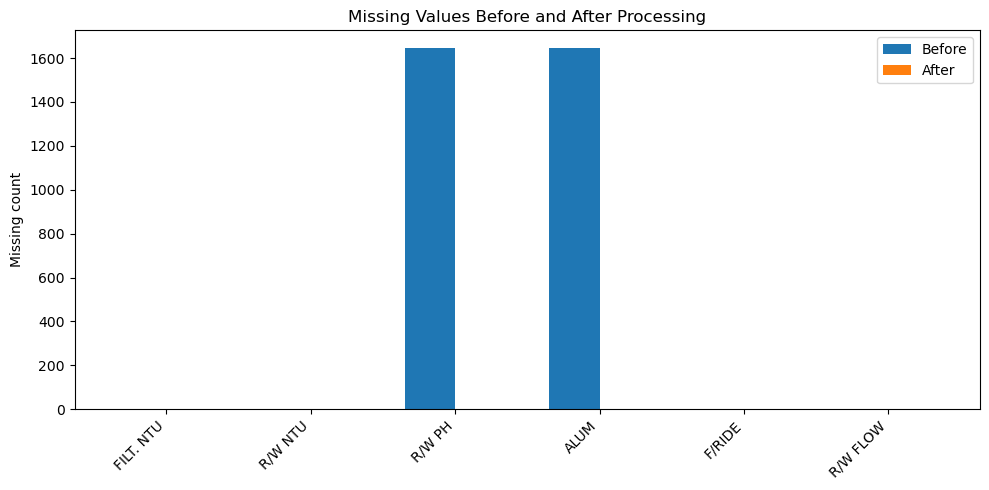

缺失值图已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_hurdle01_level_evaluation/figures/problem2_missing_before_after.png


In [13]:
missing_plot_df = missing_audit.copy()

x = np.arange(len(missing_plot_df))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width / 2, missing_plot_df["missing_count_before"], width, label="Before")
plt.bar(x + width / 2, missing_plot_df["missing_count_after"], width, label="After")
plt.xticks(x, missing_plot_df["column"], rotation=45, ha="right")
plt.ylabel("Missing count")
plt.title("Missing Values Before and After Processing")
plt.legend()
plt.tight_layout()

missing_fig_path = FIG_DIR / "problem2_missing_before_after.png"
plt.savefig(missing_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("缺失值图已保存：", missing_fig_path)


## 14. 可视化 2：原始差分、截断差分与 hurdle 目标分布

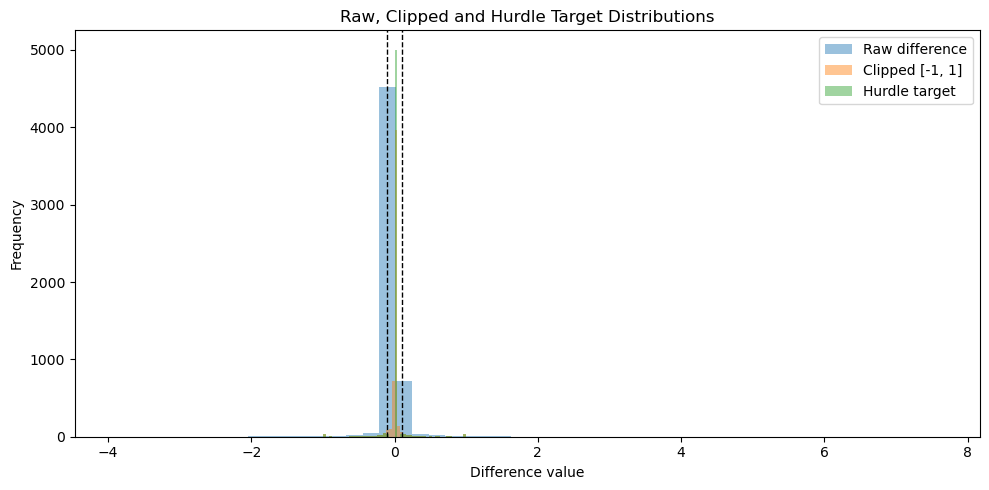

差分分布图已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_hurdle01_level_evaluation/figures/problem2_target_hurdle_distribution.png


In [14]:
raw_target_diff = clip_data[target_diff_col].dropna()
clip_target_diff = clip_data[target_clip_col].dropna()
hurdle_target_diff = clip_data[target_hurdle_col].dropna()

plt.figure(figsize=(10, 5))
plt.hist(raw_target_diff, bins=50, alpha=0.45, label="Raw difference")
plt.hist(clip_target_diff, bins=50, alpha=0.45, label="Clipped [-1, 1]")
plt.hist(hurdle_target_diff, bins=50, alpha=0.45, label="Hurdle target")
plt.axvline(-DIFF_ZERO_THRESHOLD, linestyle="--", color="black", linewidth=1)
plt.axvline(DIFF_ZERO_THRESHOLD, linestyle="--", color="black", linewidth=1)
plt.xlabel("Difference value")
plt.ylabel("Frequency")
plt.title("Raw, Clipped and Hurdle Target Distributions")
plt.legend()
plt.tight_layout()

diff_dist_fig_path = FIG_DIR / "problem2_target_hurdle_distribution.png"
plt.savefig(diff_dist_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("差分分布图已保存：", diff_dist_fig_path)

## 15. 可视化 3：模型性能对比

输出：

```text
figures/problem2_hurdle_model_test_rmse_comparison.png
figures/problem2_hurdle_model_test_r2_comparison.png
figures/problem2_model_direction_accuracy_comparison.png
```


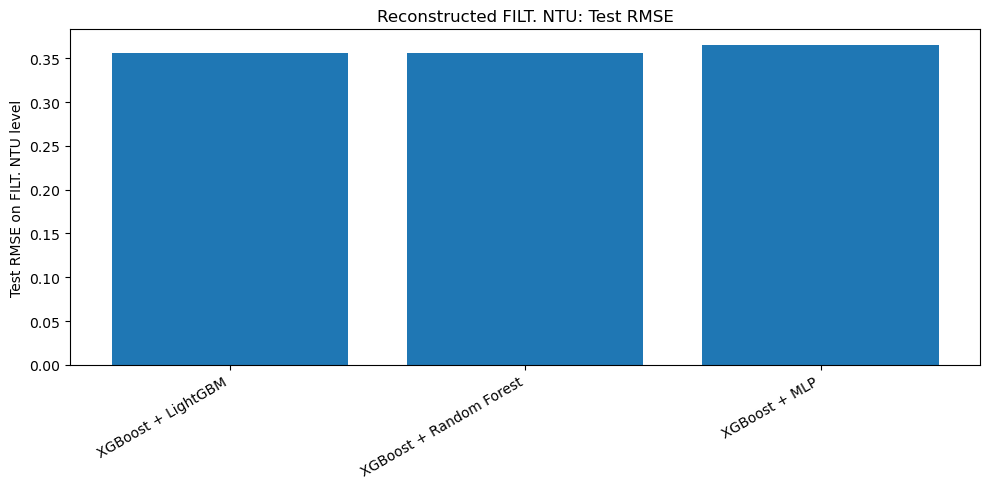

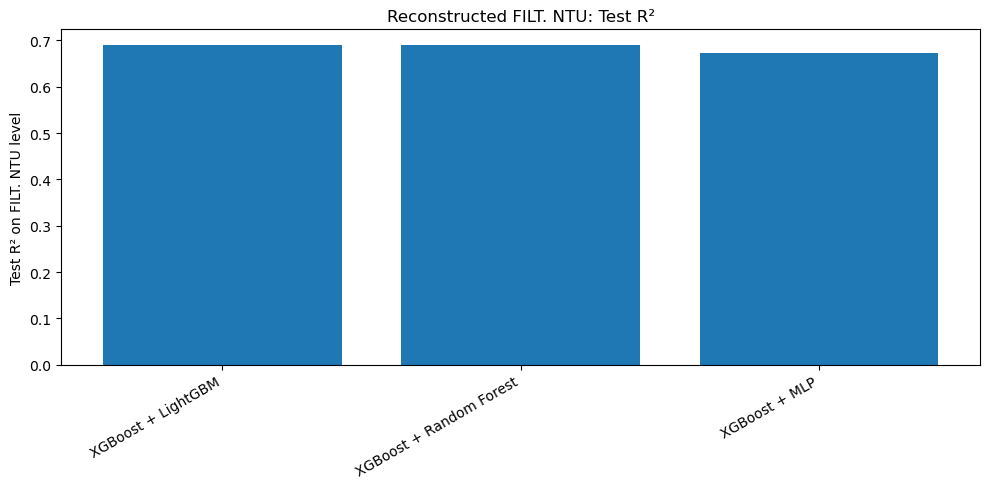

原始水平 RMSE 图已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_hurdle01_level_evaluation/figures/problem2_level_test_rmse_comparison.png
原始水平 R² 图已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_hurdle01_level_evaluation/figures/problem2_level_test_r2_comparison.png


In [15]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["model"], results_df["test_level_RMSE"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Test RMSE on FILT. NTU level")
plt.title("Reconstructed FILT. NTU: Test RMSE")
plt.tight_layout()

rmse_fig_path = FIG_DIR / "problem2_level_test_rmse_comparison.png"
plt.savefig(rmse_fig_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df["model"], results_df["test_level_R2"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Test R² on FILT. NTU level")
plt.title("Reconstructed FILT. NTU: Test R²")
plt.tight_layout()

r2_fig_path = FIG_DIR / "problem2_level_test_r2_comparison.png"
plt.savefig(r2_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("原始水平 RMSE 图已保存：", rmse_fig_path)
print("原始水平 R² 图已保存：", r2_fig_path)

## 16. 可视化 4：最佳模型实际值 vs 预测值

根据测试集 RMSE 最小选择最佳模型。


按原始水平测试 R² 选择的最佳模型： XGBoost + LightGBM


,model,stage1_classifier,stage2_regressor,n_features,train_samples,stage2_nonzero_train_samples,stage2_nonzero_test_samples,test_samples,stage1_scale_pos_weight,stage1_probability_threshold,stage1_test_Accuracy,stage1_test_Balanced_Accuracy,stage2_nonzero_train_MAE,stage2_nonzero_train_RMSE,stage2_nonzero_train_R2,stage2_nonzero_test_MAE,stage2_nonzero_test_RMSE,stage2_nonzero_test_R2,stage2_nonzero_test_Direction_Accuracy,train_level_MAE,train_level_RMSE,train_level_R2,test_level_MAE,test_level_RMSE,test_level_R2,train_diff_MAE,train_diff_RMSE,train_diff_R2,test_diff_MAE,test_diff_RMSE,test_diff_R2,test_diff_Direction_Accuracy,classifier_test_Accuracy,classifier_test_Precision,classifier_test_Recall,classifier_test_F1,classifier_test_ROC_AUC
0,XGBoost + LightGBM,XGBoost,LightGBM,6,4367,365,91,1092,6.0,0.6,0.93956,0.762238,0.223308,0.295731,0.619298,0.360846,0.477918,0.055272,0.637363,0.045078,0.209365,0.861113,0.064879,0.355889,0.689432,0.028117,0.111523,0.354392,0.035044,0.143357,-0.013616,0.924908,0.93956,0.666667,0.549451,0.60241,0.865673


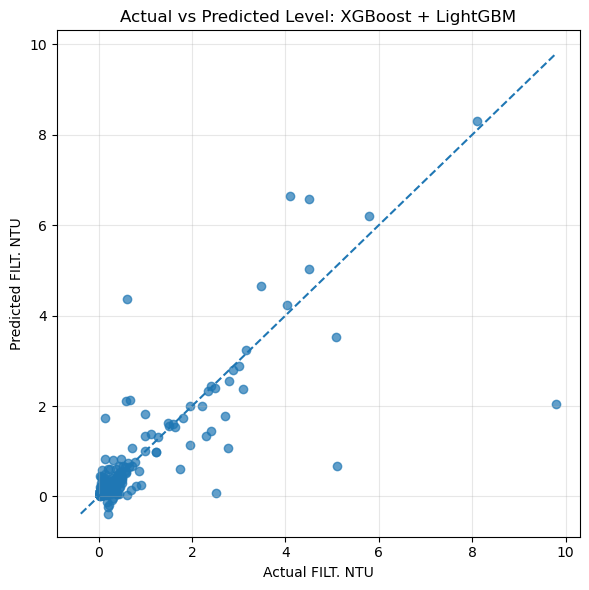

In [16]:
best_model_name = results_df.iloc[0]["model"]
best_pred_df = predictions_df[predictions_df["model"] == best_model_name].copy()

print("按原始水平测试 R² 选择的最佳模型：", best_model_name)
display(results_df.iloc[[0]])

axis_min = min(best_pred_df[TARGET_COL].min(), best_pred_df["predicted_FILT_NTU"].min())
axis_max = max(best_pred_df[TARGET_COL].max(), best_pred_df["predicted_FILT_NTU"].max())

plt.figure(figsize=(6, 6))
plt.scatter(
    best_pred_df[TARGET_COL],
    best_pred_df["predicted_FILT_NTU"],
    alpha=0.7,
)
plt.plot([axis_min, axis_max], [axis_min, axis_max], linestyle="--")
plt.xlabel("Actual FILT. NTU")
plt.ylabel("Predicted FILT. NTU")
plt.title(f"Actual vs Predicted Level: {best_model_name}")
plt.grid(alpha=0.3)
plt.tight_layout()

scatter_fig_path = FIG_DIR / "problem2_best_model_level_actual_vs_predicted.png"
plt.savefig(scatter_fig_path, dpi=300, bbox_inches="tight")
plt.show()

## 17. 可视化 5：最佳模型测试集时间曲线

虽然数据划分是随机的，但为了观察波动模式，这里按 `DATETIME` 排序后画测试集实际/预测曲线。


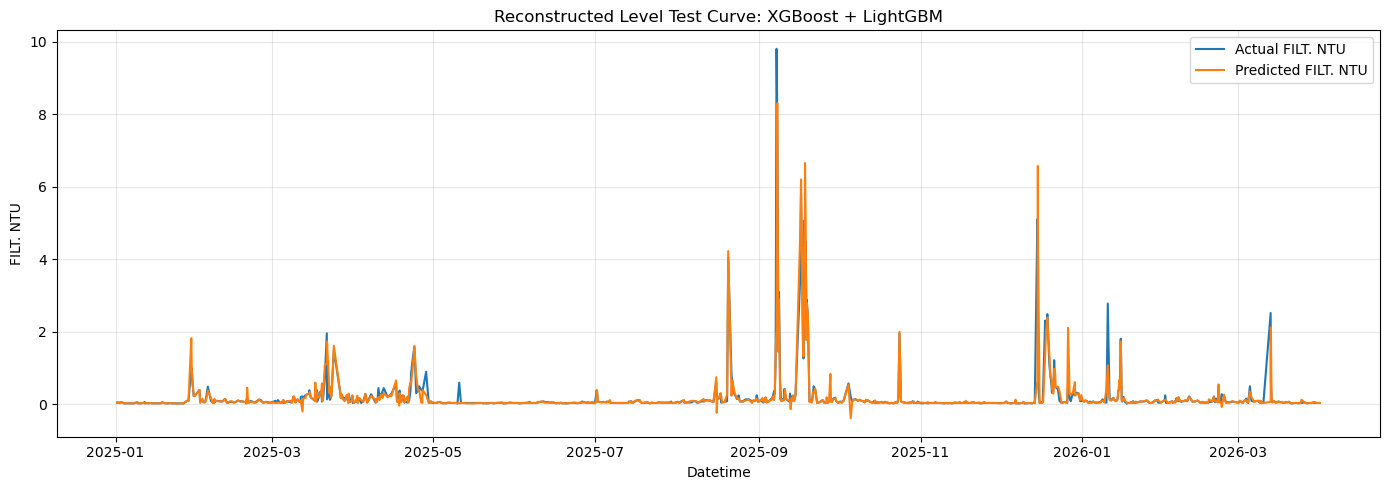

In [17]:
plt.figure(figsize=(14, 5))
plt.plot(
    best_pred_df["DATETIME"],
    best_pred_df[TARGET_COL],
    label="Actual FILT. NTU",
    linewidth=1.5,
)
plt.plot(
    best_pred_df["DATETIME"],
    best_pred_df["predicted_FILT_NTU"],
    label="Predicted FILT. NTU",
    linewidth=1.5,
)
plt.xlabel("Datetime")
plt.ylabel("FILT. NTU")
plt.title(f"Reconstructed Level Test Curve: {best_model_name}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

ts_fig_path = FIG_DIR / "problem2_best_model_level_test_timeseries.png"
plt.savefig(ts_fig_path, dpi=300, bbox_inches="tight")
plt.show()

## 18. 可视化 6：最佳模型残差分布与残差曲线

输出：

```text
figures/problem2_best_hurdle_model_residual_distribution.png
figures/problem2_best_hurdle_model_residual_timeseries.png
```


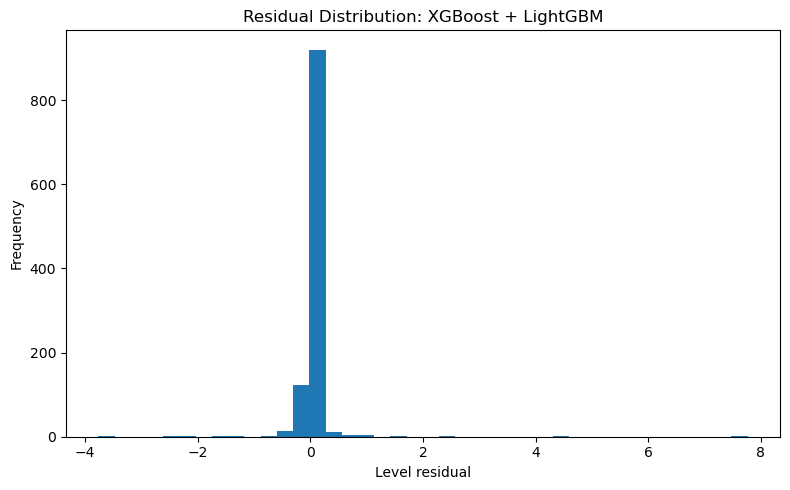

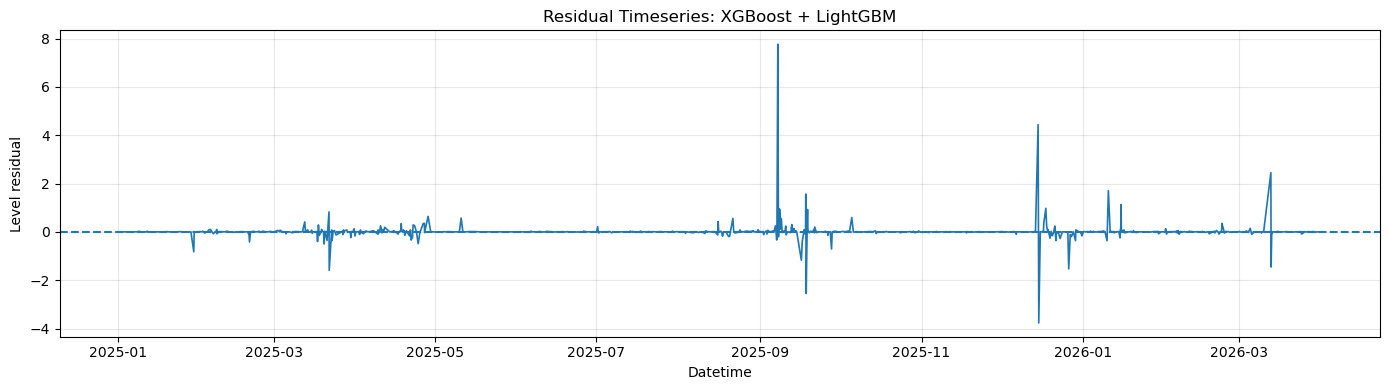

残差分布图已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_hurdle01_level_evaluation/figures/problem2_best_hurdle_model_residual_distribution.png
残差曲线图已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_hurdle01_level_evaluation/figures/problem2_best_hurdle_model_residual_timeseries.png


In [18]:
plt.figure(figsize=(8, 5))
plt.hist(best_pred_df["level_residual"], bins=40)
plt.xlabel("Level residual")
plt.ylabel("Frequency")
plt.title(f"Residual Distribution: {best_model_name}")
plt.tight_layout()

resid_dist_fig_path = FIG_DIR / "problem2_best_hurdle_model_residual_distribution.png"
plt.savefig(resid_dist_fig_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(
    best_pred_df["DATETIME"],
    best_pred_df["level_residual"],
    linewidth=1.2,
)
plt.axhline(0, linestyle="--")
plt.xlabel("Datetime")
plt.ylabel("Level residual")
plt.title(f"Residual Timeseries: {best_model_name}")
plt.grid(alpha=0.3)
plt.tight_layout()

resid_ts_fig_path = FIG_DIR / "problem2_best_hurdle_model_residual_timeseries.png"
plt.savefig(resid_ts_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("残差分布图已保存：", resid_dist_fig_path)
print("残差曲线图已保存：", resid_ts_fig_path)


## 19. 可视化 7：特征重要性

如果有树模型特征重要性，则绘制每个模型 Top 15 特征。


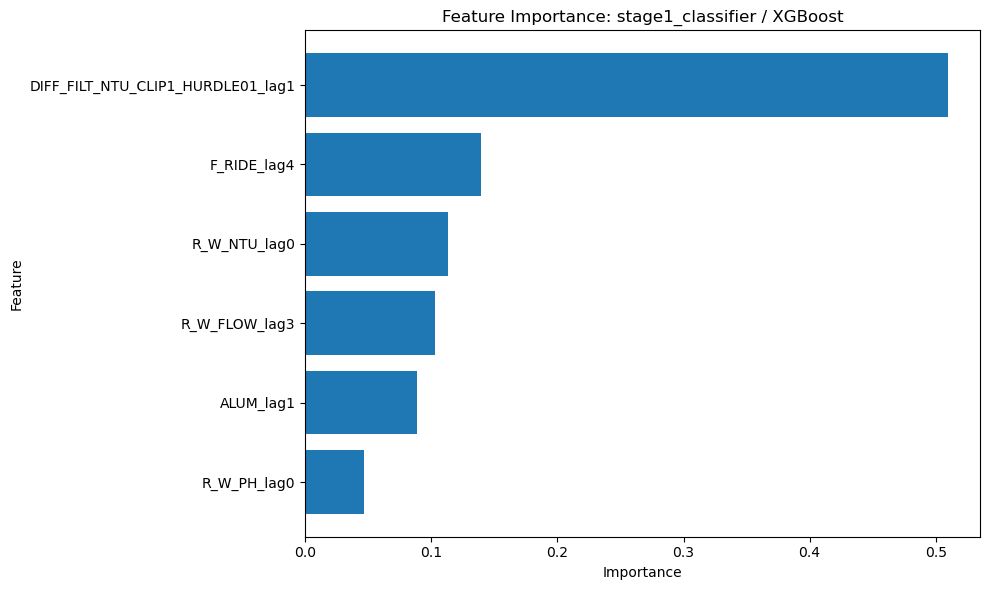

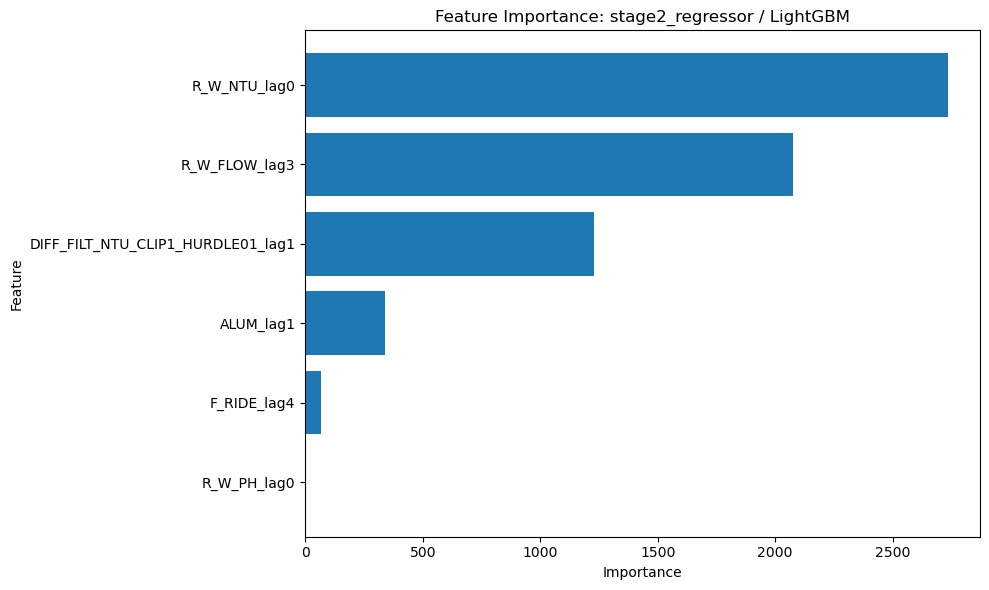

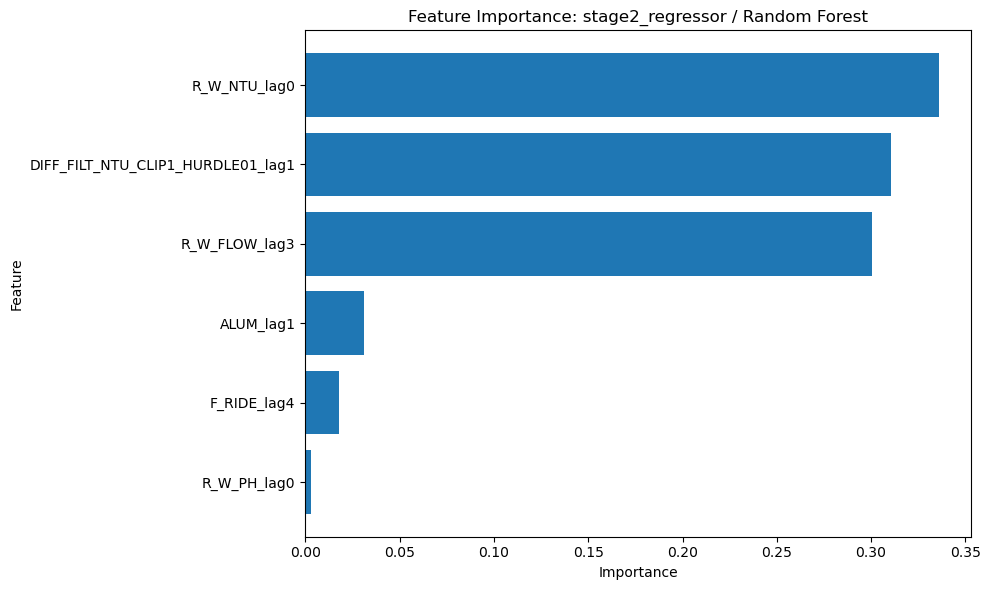

特征重要性图：
/Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_hurdle01_level_evaluation/figures/problem2_feature_importance_stage1_classifier_XGBoost.png
/Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_hurdle01_level_evaluation/figures/problem2_feature_importance_stage2_regressor_LightGBM.png
/Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_hurdle01_level_evaluation/figures/problem2_feature_importance_stage2_regressor_Random_Forest.png


In [19]:
importance_fig_paths = []

for (stage, model_name), temp in importance_df.groupby(["stage", "model"]):
    temp = temp.sort_values("importance", ascending=False).head(15)
    plt.figure(figsize=(10, 6))
    plt.barh(temp["feature"][::-1], temp["importance"][::-1])
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(f"Feature Importance: {stage} / {model_name}")
    plt.tight_layout()

    fig_path = FIG_DIR / (
        f"problem2_feature_importance_{stage}_{model_name}.png"
        .replace(" ", "_")
        .replace("/", "_")
    )
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    importance_fig_paths.append(fig_path)

print("特征重要性图：")
for path in importance_fig_paths:
    print(path)

## 20. 输出汇总工作簿和最终摘要

In [20]:
summary_workbook_path = OUTPUT_DIR / "problem2_diff_hurdle01_summary.xlsx"

with pd.ExcelWriter(summary_workbook_path, engine="openpyxl") as writer:
    missing_audit.to_excel(writer, sheet_name="missing_audit", index=False)
    clip_audit_df.to_excel(writer, sheet_name="target_transform", index=False)
    feature_summary_df.to_excel(writer, sheet_name="feature_summary", index=False)
    classifier_results_df.to_excel(writer, sheet_name="stage1_classifier", index=False)
    stage1_tuning_df.to_excel(writer, sheet_name="stage1_tuning", index=False)
    results_df.to_excel(writer, sheet_name="hurdle_model_results", index=False)
    predictions_df.to_excel(writer, sheet_name="test_predictions", index=False)
    importance_df.to_excel(writer, sheet_name="feature_importance", index=False)

final_summary = pd.DataFrame([
    {"item": "model_family", "value": "Two-stage hurdle model"},
    {
        "item": "zero_mapping_rule",
        "value": f"map abs(clipped difference) < {DIFF_ZERO_THRESHOLD} to zero",
    },
    {"item": "stage1_classifier", "value": "XGBoost"},
    {"item": "stage1_scale_pos_weight", "value": best_scale_pos_weight},
    {"item": "stage1_probability_threshold", "value": best_hurdle_prob_threshold},
    {
        "item": "stage2_regressors",
        "value": "MLP, LightGBM, Random Forest fitted directly to signed nonzero targets",
    },
    {"item": "model_ranking_rule", "value": "highest test R2 on reconstructed FILT. NTU level"},
    {"item": "best_stage2_model", "value": results_df.iloc[0]["model"]},
    {
        "item": "stage1_test_Accuracy",
        "value": classifier_test_metrics["Accuracy"],
    },
    {
        "item": "stage1_test_F1",
        "value": classifier_test_metrics["F1"],
    },
    {
        "item": "best_stage2_nonzero_test_R2",
        "value": results_df.iloc[0]["stage2_nonzero_test_R2"],
    },
    {"item": "best_test_level_MAE", "value": results_df.iloc[0]["test_level_MAE"]},
    {"item": "best_test_level_RMSE", "value": results_df.iloc[0]["test_level_RMSE"]},
    {"item": "best_test_level_R2", "value": results_df.iloc[0]["test_level_R2"]},
    {"item": "best_test_diff_R2", "value": results_df.iloc[0]["test_diff_R2"]},
])

final_summary_path = OUTPUT_DIR / "problem2_diff_hurdle01_final_summary.xlsx"
final_summary.to_excel(final_summary_path, index=False)
display(final_summary)

,item,value
0,model_family,Two-stage hurdle model
1,zero_mapping_rule,map abs(clipped difference) < 0.1 to zero
2,stage1_classifier,XGBoost
3,stage1_scale_pos_weight,6.0
4,stage1_probability_threshold,0.6
5,stage2_regressors,"MLP, LightGBM, Random Forest fitted directly t..."
6,model_ranking_rule,highest test R2 on reconstructed FILT. NTU level
7,best_stage2_model,XGBoost + LightGBM
8,stage1_test_Accuracy,0.93956
9,stage1_test_F1,0.60241


## 21. 论文中可以使用的说明

```text
本文将绝对值小于 0.1 的滤后水浊度差分映射为 0，并构建两阶段 Hurdle 模型。第一阶段使用经交叉验证调优的 XGBoost 分类器判断是否发生显著变化；第二阶段仅使用真实非零训练样本，分别采用 MLP、LightGBM 和随机森林直接拟合带正负号的差分值。模型训练目标仍为差分值。测试评估时，将每个样本前一时刻的真实 FILT. NTU 与预测差分相加，重建当前时刻的 FILT. NTU，并以重建值和当前真实原值计算 MAE、RMSE 与 R²。前一时刻原值仅用于评估重建，不作为模型输入特征。
```

In [21]:
print("=" * 80)
print("问题二：零/非零分类 + 带符号非零回归 Hurdle 流程已完成。")
print("=" * 80)

print("第一阶段分类结果：", classifier_results_path)
print("第一阶段调参结果：", stage1_tuning_path)
print("Hurdle 模型结果：", results_path)
print("测试集预测：", predictions_path)
print("特征重要性：", importance_path)
print("汇总工作簿：", summary_workbook_path)
print("最终摘要：", final_summary_path)
print("模型目录：", MODEL_DIR)

display(classifier_results_df)
display(results_df)

问题二：零/非零分类 + 带符号非零回归 Hurdle 流程已完成。
第一阶段分类结果： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_hurdle01_level_evaluation/problem2_diff_hurdle01_classifier_results.xlsx
第一阶段调参结果： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_hurdle01_level_evaluation/problem2_diff_hurdle01_stage1_tuning.xlsx
Hurdle 模型结果： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_hurdle01_level_evaluation/problem2_diff_hurdle01_model_results.xlsx
测试集预测： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_hurdle01_level_evaluation/problem2_diff_hurdle01_test_predictions.xlsx
特征重要性： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_hurdle01_level_evaluation/problem2_diff_hurdle01_feature_importance.xlsx
汇总工作簿： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_hurdle01_level_evaluation/problem2_diff_hurdle01_summary.xlsx
最终摘要： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_hurdle01_level_evaluation/problem2_diff_hurdle01_final_summary.xlsx
模型目录： /Users/jinyu/workspace/2026亚太杯/outputs/proble

,split,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,train,0.932906,0.756736,0.610429,0.545205,0.575977,0.920341
1,test,0.939560,0.762238,0.666667,0.549451,0.602410,0.865673


,model,stage1_classifier,stage2_regressor,n_features,train_samples,stage2_nonzero_train_samples,stage2_nonzero_test_samples,test_samples,stage1_scale_pos_weight,stage1_probability_threshold,stage1_test_Accuracy,stage1_test_Balanced_Accuracy,stage2_nonzero_train_MAE,stage2_nonzero_train_RMSE,stage2_nonzero_train_R2,stage2_nonzero_test_MAE,stage2_nonzero_test_RMSE,stage2_nonzero_test_R2,stage2_nonzero_test_Direction_Accuracy,train_level_MAE,train_level_RMSE,train_level_R2,test_level_MAE,test_level_RMSE,test_level_R2,train_diff_MAE,train_diff_RMSE,train_diff_R2,test_diff_MAE,test_diff_RMSE,test_diff_R2,test_diff_Direction_Accuracy,classifier_test_Accuracy,classifier_test_Precision,classifier_test_Recall,classifier_test_F1,classifier_test_ROC_AUC
0,XGBoost + LightGBM,XGBoost,LightGBM,6,4367,365,91,1092,6.0,0.6,0.93956,0.762238,0.223308,0.295731,0.619298,0.360846,0.477918,0.055272,0.637363,0.045078,0.209365,0.861113,0.064879,0.355889,0.689432,0.028117,0.111523,0.354392,0.035044,0.143357,-0.013616,0.924908,0.93956,0.666667,0.549451,0.60241,0.865673
1,XGBoost + Random Forest,XGBoost,Random Forest,6,4367,365,91,1092,6.0,0.6,0.93956,0.762238,0.234106,0.313211,0.572965,0.349452,0.468364,0.092666,0.615385,0.043355,0.209397,0.861071,0.062417,0.356004,0.689230,0.026382,0.108209,0.392192,0.032762,0.137987,0.060893,0.923993,0.93956,0.666667,0.549451,0.60241,0.865673
2,XGBoost + MLP,XGBoost,MLP,6,4367,365,91,1092,6.0,0.6,0.93956,0.762238,0.347242,0.466134,0.054172,0.367577,0.496984,-0.021611,0.549451,0.048847,0.231992,0.829471,0.062383,0.364961,0.673396,0.031929,0.136428,0.033837,0.032787,0.145361,-0.042162,0.921245,0.93956,0.666667,0.549451,0.60241,0.865673
